In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"SVM_Data.csv")

In [3]:
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Med_1_mL       400 non-null    float64
 1   Med_2_mL       400 non-null    float64
 2   Virus Present  400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


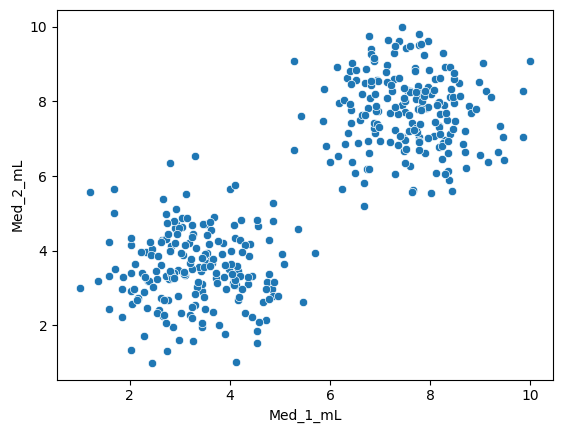

In [7]:
sns.scatterplot(x ='Med_1_mL' ,y= 'Med_2_mL',data=df)
plt.show()

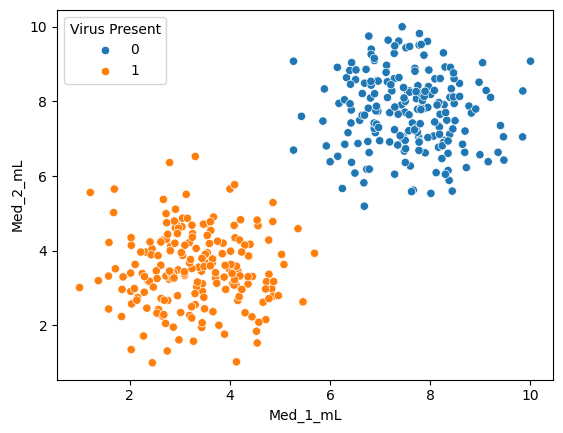

In [ ]:
sns.scatterplot(x ='Med_1_mL' ,y= 'Med_2_mL',hue='Virus Present',data=df)
plt.show() # hue

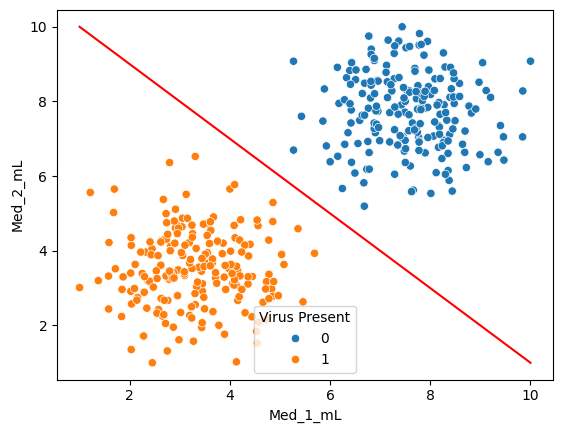

In [6]:
sns.scatterplot(x ='Med_1_mL' ,y= 'Med_2_mL',hue='Virus Present',data=df)
x = np.linspace(1,10,100)
w = -1
b =11

y = w*x +b
plt.plot(x,y,color = 'red')

plt.show()

In [8]:
x = df.drop('Virus Present',axis=1)
y = df['Virus Present']

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size= 0.2 , random_state = 10)

### **default features**
---

In [39]:
from sklearn.svm import SVC
model =SVC() # kernel by default is rbf , C = 1.0
model

SVC()

In [40]:
model.fit(x_train,y_train)

SVC()

c:\Users\e\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


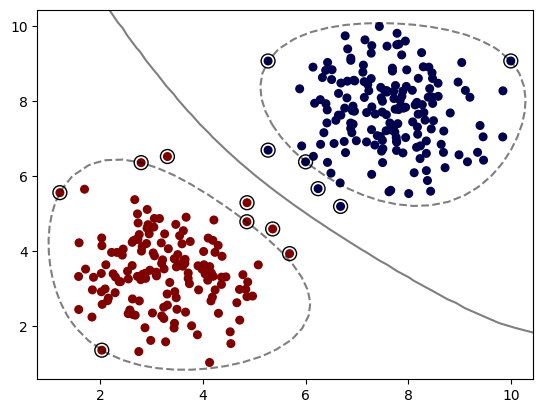

In [41]:
from svm_margin_plot import plot_svm_boundary
plot_svm_boundary(model,x_train,y_train) # Overfitting 

### **rbf kernel + large gamma**
---

In [42]:
model =SVC(kernel='rbf',gamma=50)
model.fit(x_train,y_train)

SVC(gamma=50)

c:\Users\e\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


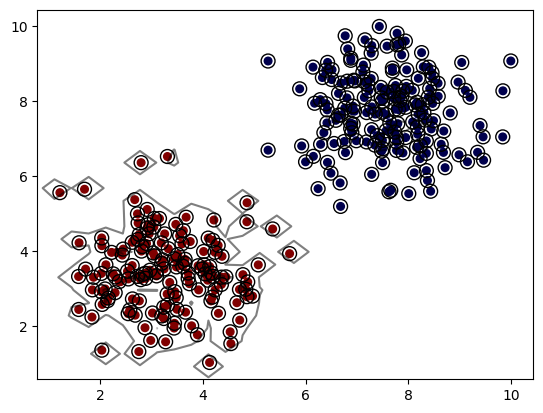

In [44]:
plot_svm_boundary(model,x_train,y_train) # Overfitting sureeee

### **linear kernel**
---

In [45]:
model = SVC(kernel="linear")
model

SVC(kernel='linear')

In [46]:
model.fit(x_train,y_train)

SVC(kernel='linear')

c:\Users\e\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


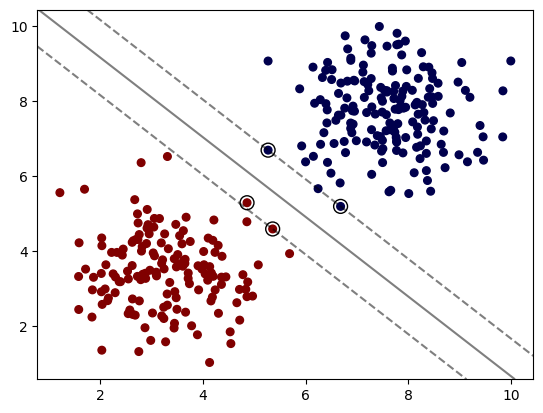

In [ ]:
plot_svm_boundary(model,x_train,y_train) # Perfect (cuz data is linear btw)

In [48]:
model = SVC(kernel="linear", C=0.01)
model

SVC(C=0.01, kernel='linear')

In [ ]:
model.fit(x_train,y_train)

SVC(C=0.01, kernel='linear')

c:\Users\e\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


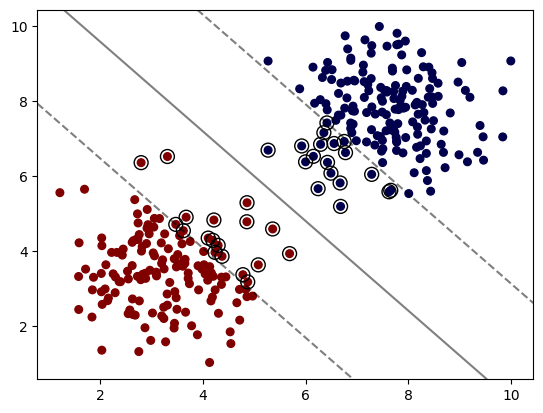

In [ ]:
plot_svm_boundary(model,x_train,y_train) # decrease C >>>> Increase the

### **The best way (we have to make sure that data is linear for this)**
---

In [ ]:
model = SVC() # model with no parms
# لو الداتا مش خطية اصلا وعملت كده ف الجريد سيرش هياخد وقت طويل جدااا بالذات لو داتا كتير عشان يحاول ي فيت خط 

In [58]:
params={
    'kernel':['linear','poly','rbf'],
    'C' :[0.01,0.1,1,10],
    'gamma':[0.01,0.1,1,10]
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(model,params)

In [61]:
grid.fit(x_train,y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'gamma': [0.01, 0.1, 1, 10],
                         'kernel': ['linear', 'poly', 'rbf']})

In [62]:
grid.best_estimator_

SVC(C=0.01, gamma=0.01, kernel='linear')

### **Apply best model**
---

In [63]:
best_model = SVC(C=0.01, gamma=0.01, kernel='linear')
best_model.fit(x_train,y_train)

SVC(C=0.01, gamma=0.01, kernel='linear')

c:\Users\e\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


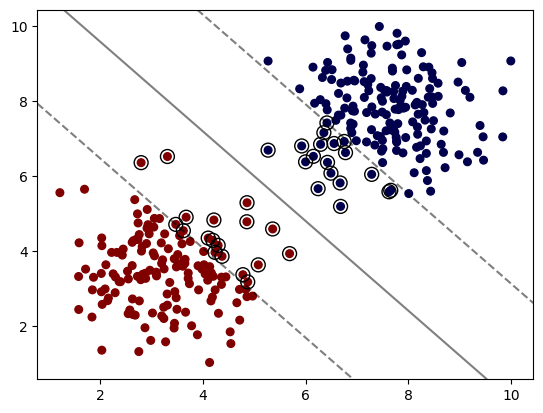

In [64]:
plot_svm_boundary(best_model,x_train,y_train)

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = best_model.predict(x_test)
accuracy_score(y_test,y_pred)

# svm is perfect with small and medium data

1.0